In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display
warnings.filterwarnings('ignore')
dataset = pd.read_csv(r"C:\Users\acer\Downloads\QVI_data.csv")
display(dataset.head())
display(dataset.info())
display(dataset.describe())

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


None

,LYLTY_CARD_NBR,STORE_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PACK_SIZE
count,2.648340e+05,264834.000000,2.648340e+05,264834.000000,264834.000000,264834.000000,264834.000000
mean,1.355488e+05,135.079423,1.351576e+05,56.583554,1.905813,7.299346,182.425512
std,8.057990e+04,76.784063,7.813292e+04,32.826444,0.343436,2.527241,64.325148
min,1.000000e+03,1.000000,1.000000e+00,1.000000,1.000000,1.500000,70.000000
25%,7.002100e+04,70.000000,6.760050e+04,28.000000,2.000000,5.400000,150.000000
50%,1.303570e+05,130.000000,1.351365e+05,56.000000,2.000000,7.400000,170.000000
75%,2.030940e+05,203.000000,2.026998e+05,85.000000,2.000000,9.200000,175.000000
max,2.373711e+06,272.000000,2.415841e+06,114.000000,5.000000,29.500000,380.000000


In [4]:
dataset['DATE'] = pd.to_datetime(dataset['DATE'])
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   LYLTY_CARD_NBR    264834 non-null  int64         
 1   DATE              264834 non-null  datetime64[ns]
 2   STORE_NBR         264834 non-null  int64         
 3   TXN_ID            264834 non-null  int64         
 4   PROD_NBR          264834 non-null  int64         
 5   PROD_NAME         264834 non-null  object        
 6   PROD_QTY          264834 non-null  int64         
 7   TOT_SALES         264834 non-null  float64       
 8   PACK_SIZE         264834 non-null  int64         
 9   BRAND             264834 non-null  object        
 10  LIFESTAGE         264834 non-null  object        
 11  PREMIUM_CUSTOMER  264834 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(6), object(4)
memory usage: 24.2+ MB


## Data Preparation

In [9]:
# Change data transaction (bon) into monthly data(store)
# 1. Buat Kolom YEARMONTH (Format: YYYYMM)
# Ini penting agar kita bisa mengelompokkan data per bulan
dataset['YEARMONTH'] = dataset['DATE'].dt.year * 100 + dataset['DATE'].dt.month
# Kita butuh kolom ini untuk menghitung rata-rata harga per toko nanti
dataset['UNIT_PRICE'] = dataset['TOT_SALES'] / dataset['PROD_QTY']
# 2. Hitung Metrik Bulanan per Toko
# Kita butuh: Total Sales, Jumlah Customer Unik, Transaksi per Customer, Harga per Unit
measureOverTime = dataset.groupby(['STORE_NBR', 'YEARMONTH']).agg(
    totSales=('TOT_SALES', 'sum'),
    nCustomers=('LYLTY_CARD_NBR', 'nunique'),
    nTxnPerCust=('TXN_ID', 'count'), # Total transaksi dulu
    nChipsPerTxn=('PROD_QTY', 'sum'), # Total qty dulu
    avgPricePerUnit=('UNIT_PRICE', 'mean')
).reset_index()
# Hitung rata-rata transaksi per customer
measureOverTime['nTxnPerCust'] = measureOverTime['nTxnPerCust'] / measureOverTime['nCustomers']
# Hitung rata-rata chips per customer (opsional, tapi ada di template R)
measureOverTime['nChipsPerTxn'] = measureOverTime['nChipsPerTxn'] / measureOverTime['nCustomers']
print("--- Sample Data Bulanan ---")
display(measureOverTime.head())
# 3. Filter Toko yang Datanya Lengkap (Full Observation)
# Kita hanya mau membandingkan toko yang buka PENUH selama 12 bulan (Juli 2018 - Juni 2019)
store_counts = measureOverTime['STORE_NBR'].value_counts()
stores_full_obs = store_counts[store_counts == 12].index

print(f"\nJumlah toko awal: {measureOverTime['STORE_NBR'].nunique()}")
print(f"Jumlah toko dengan data penuh (12 bulan): {len(stores_full_obs)}")
# Filter data hanya untuk toko-toko tersebut
pretrial_measures = measureOverTime[measureOverTime['STORE_NBR'].isin(stores_full_obs)]

# Pisahkan data Pre-Trial (Sebelum Feb 2019) untuk analisis korelasi
# Trial dimulai Feb 2019, jadi kita cari kembaran berdasarkan perilaku MASA LALU (sebelum Feb)
pretrial_data = pretrial_measures[pretrial_measures['YEARMONTH'] < 201902]

print(f"Data siap untuk analisis korelasi. Jumlah baris Pre-Trial: {len(pretrial_data)}")

--- Sample Data Bulanan ---


,STORE_NBR,YEARMONTH,totSales,nCustomers,nTxnPerCust,nChipsPerTxn,avgPricePerUnit
0,1,201807,206.9,49,1.061224,1.265306,3.384615
1,1,201808,176.1,42,1.023810,1.285714,3.329070
2,1,201809,278.8,59,1.050847,1.271186,3.685484
3,1,201810,188.1,44,1.022727,1.318182,3.288889
4,1,201811,192.6,46,1.021739,1.239130,3.412766



Jumlah toko awal: 272
Jumlah toko dengan data penuh (12 bulan): 260
Data siap untuk analisis korelasi. Jumlah baris Pre-Trial: 1820


## Make Function for Twin
Sekarang kita masuk ke inti masalah: Mencari "Kembaran" (Control Store) untuk Toko 77.

Di R Solution , mereka menggunakan dua rumus matematika untuk mencari kembaran:

Korelasi (Correlation): Apakah grafiknya naik-turun barengan?

Jarak Magnitudo (Magnitude Distance): Apakah angka penjualannya mirip? (Misal: Toko A omset 100juta, Toko B omset 10juta. Korelasinya mungkin sama-sama naik, tapi Magnitudonya beda jauh. Kita cari yang dekat).

In [10]:
# --- FUNGSI 1: HITUNG KORELASI ---
def calculate_correlation(input_data, metric, trial_store):
    output = []
    trial_data = input_data[input_data['STORE_NBR'] == trial_store][metric].reset_index(drop=True)
    
    for store in input_data['STORE_NBR'].unique():
        if store == trial_store: continue
        
        control_data = input_data[input_data['STORE_NBR'] == store][metric].reset_index(drop=True)
        
        # Hitung korelasi Pearson
        correlation = trial_data.corr(control_data)
        output.append({'Store1': trial_store, 'Store2': store, 'corr_measure': correlation})
        
    return pd.DataFrame(output)

# --- FUNGSI 2: HITUNG JARAK MAGNITUDO (STANDARDIZED) ---
def calculate_magnitude_distance(input_data, metric, trial_store):
    output = []
    trial_data = input_data[input_data['STORE_NBR'] == trial_store].set_index('YEARMONTH')[metric]
    
    for store in input_data['STORE_NBR'].unique():
        if store == trial_store: continue
        
        control_data = input_data[input_data['STORE_NBR'] == store].set_index('YEARMONTH')[metric]
        
        # Hitung selisih absolut per bulan
        diff = abs(trial_data - control_data).mean()
        output.append({'Store1': trial_store, 'Store2': store, 'measure': diff})
        
    dist_table = pd.DataFrame(output)
    
    # Standardisasi ke skala 0-1 (Sesuai logika R: 1 artinya paling mirip/jarak 0)
    min_dist = dist_table['measure'].min()
    max_dist = dist_table['measure'].max()
    
    # Rumus: 1 - ((x - min) / (max - min))
    dist_table['mag_measure'] = 1 - ((dist_table['measure'] - min_dist) / (max_dist - min_dist))
    
    return dist_table[['Store1', 'Store2', 'mag_measure']]

print("Fungsi pencarian kembaran sudah siap!")

Fungsi pencarian kembaran sudah siap!


#### Store 77

In [11]:
trial_store = 77

# 1. Hitung Skor untuk SALES
corr_sales = calculate_correlation(pretrial_data, 'totSales', trial_store)
mag_sales = calculate_magnitude_distance(pretrial_data, 'totSales', trial_store)
# Gabung skor sales (Rata-rata korelasi & magnitudo)
score_sales = pd.merge(corr_sales, mag_sales, on=['Store1', 'Store2'])
score_sales['scoreNSales'] = 0.5 * score_sales['corr_measure'] + 0.5 * score_sales['mag_measure']

# 2. Hitung Skor untuk CUSTOMER
corr_cust = calculate_correlation(pretrial_data, 'nCustomers', trial_store)
mag_cust = calculate_magnitude_distance(pretrial_data, 'nCustomers', trial_store)
# Gabung skor customer
score_cust = pd.merge(corr_cust, mag_cust, on=['Store1', 'Store2'])
score_cust['scoreNCust'] = 0.5 * score_cust['corr_measure'] + 0.5 * score_cust['mag_measure']

# 3. GABUNG SEMUA (Final Composite Score)
score_control = pd.merge(score_sales, score_cust, on=['Store1', 'Store2'])
score_control['finalControlScore'] = 0.5 * score_control['scoreNSales'] + 0.5 * score_control['scoreNCust']

# 4. SIAPA PEMENANGNYA?
top_control = score_control.sort_values('finalControlScore', ascending=False).head()
print("--- TOP 5 KANDIDAT CONTROL STORE UNTUK TOKO 77 ---")
display(top_control)

# Ambil Toko Ranking 1
best_control_store = top_control.iloc[0]['Store2']
print(f"\nControl Store terpilih untuk Toko 77 adalah: {int(best_control_store)}")

--- TOP 5 KANDIDAT CONTROL STORE UNTUK TOKO 77 ---


,Store1,Store2,corr_measure_x,mag_measure_x,scoreNSales,corr_measure_y,mag_measure_y,scoreNCust,finalControlScore
220,77,233,0.903774,1.000000,0.951887,0.990358,1.000000,0.995179,0.973533
38,77,41,0.783232,0.977927,0.880579,0.844219,0.981481,0.912850,0.896715
15,77,17,0.842668,0.886125,0.864397,0.747308,0.969136,0.858222,0.861309
240,77,254,0.577108,0.931544,0.754326,0.916208,0.941358,0.928783,0.841555
107,77,115,0.689159,0.942700,0.815929,0.718882,0.970679,0.844780,0.830355



Control Store terpilih untuk Toko 77 adalah: 233


## Visual Validation and Assesment
Kita harus menjawab pertanyaan Bos Julia: "Apakah uji coba di Toko 77 benar-benar meningkatkan penjualan secara signifikan?"

Sesuai kunci jawaban , kita perlu melakukan dua hal:

Cek Visual: Pastikan garis grafik Toko 77 dan 233 memang "berimpitan" sebelum Februari 2019 (Pre-Trial).

Uji Statistik: Hitung apakah lonjakan penjualan di masa Trial (Feb-April) itu "nyata" (signifikan) atau cuma kebetulan.

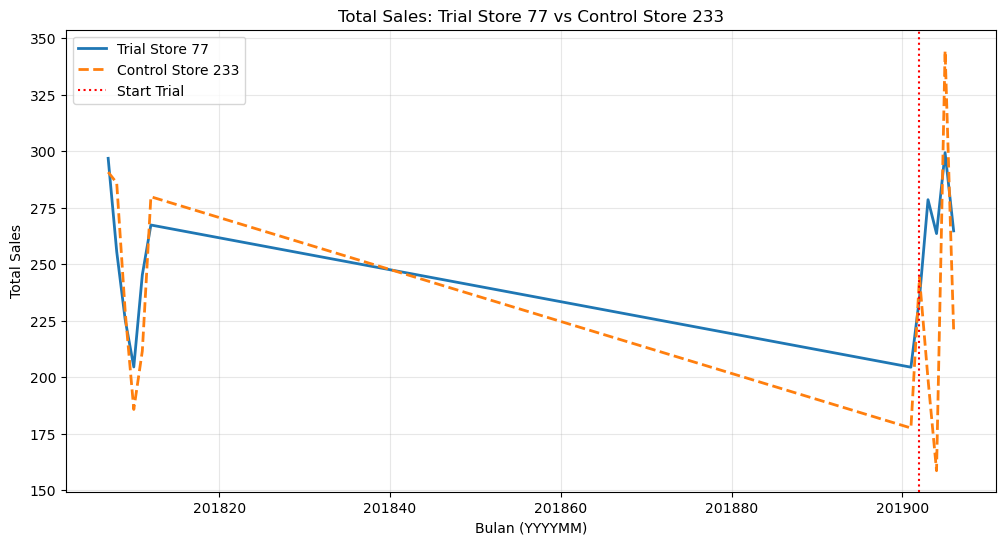

Scaling Factor: 1.0236
Standard Deviation (Pre-Trial): 0.0499

--- HASIL UJI SIGNIFIKANSI (T-SCORE) ---
Bulan 201902: T-Value = -1.1835
   ❌ Tidak Signifikan.
Bulan 201903: T-Value = 7.3391
   ✅ SIGNIFIKAN! Sales naik drastis.
Bulan 201904: T-Value = 12.4764
   ✅ SIGNIFIKAN! Sales naik drastis.


In [12]:
# --- A. VISUALISASI TREND (Sales) ---
# Kita bandingkan Toko 77 (Trial) vs Toko 233 (Control)
store_trial = 77
store_control = 233

# Ambil data sales kedua toko
trial_sales = measureOverTime[measureOverTime['STORE_NBR'] == store_trial].set_index('YEARMONTH')['totSales']
control_sales = measureOverTime[measureOverTime['STORE_NBR'] == store_control].set_index('YEARMONTH')['totSales']

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(trial_sales, label=f'Trial Store {store_trial}', linewidth=2)
plt.plot(control_sales, label=f'Control Store {store_control}', linewidth=2, linestyle='--')

# Garis batas mulai Trial (Feb 2019)
plt.axvline(x=201902, color='red', linestyle=':', label='Start Trial')
plt.title(f'Total Sales: Trial Store {store_trial} vs Control Store {store_control}')
plt.xlabel('Bulan (YYYYMM)')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- B. UJI DAMPAK (ASSESSMENT) ---
# 1. Hitung Scaling Factor (Faktor Penyeimbang)
# Kita samakan level sales Control agar setara Trial di masa lalu
pretrial_trial = trial_sales[trial_sales.index < 201902].sum()
pretrial_control = control_sales[control_sales.index < 201902].sum()
scaling_factor = pretrial_trial / pretrial_control

print(f"Scaling Factor: {scaling_factor:.4f}")

# 2. Scale Sales Control Store
scaled_control_sales = control_sales * scaling_factor

# 3. Hitung % Perbedaan (Diff)
percentage_diff = abs(trial_sales - scaled_control_sales) / scaled_control_sales

# 4. Hitung Standar Deviasi dari Perbedaan di Masa Pre-Trial
std_dev = percentage_diff[percentage_diff.index < 201902].std()
print(f"Standard Deviation (Pre-Trial): {std_dev:.4f}")

# 5. Cek Signifikansi di Masa Trial (Feb, Mar, Apr 2019)
print("\n--- HASIL UJI SIGNIFIKANSI (T-SCORE) ---")
trial_months = [201902, 201903, 201904]

for month in trial_months:
    # Ambil sales asli & scaled
    trial_val = trial_sales.loc[month]
    control_val = scaled_control_sales.loc[month]
    
    # Hitung t-value: (Perbedaan) / Std_Dev
    # Ini mengukur seberapa "jauh" penyimpangannya dalam satuan standar deviasi
    t_value = (trial_val - control_val) / control_val / std_dev
    
    print(f"Bulan {month}: T-Value = {t_value:.4f}")
    
    # Batas kritis t-value untuk confidence 95% (df=7) adalah sekitar 2.365
    # Tapi di kunci jawaban R mereka pakai 2 * stdDev sebagai threshold visual
    if t_value > 2:
        print("   ✅ SIGNIFIKAN! Sales naik drastis.")
    else:
        print("   ❌ Tidak Signifikan.")

## Apply all the step for Store 77,86 and 88



 ANALISIS TRIAL STORE: 77 
✅ Control Store Terpilih: 233


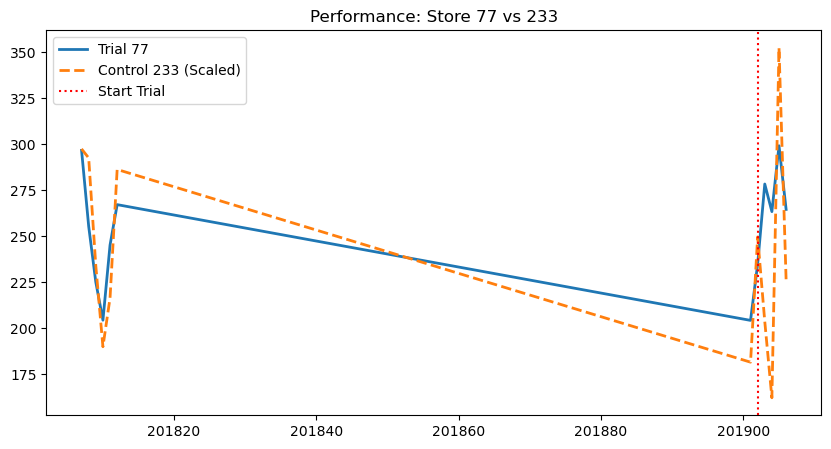

--- HASIL UJI SIGNIFIKANSI ---
Bulan 201902: T-Score -1.18 -> Tidak Signifikan ❌
Bulan 201903: T-Score 7.34 -> SIGNIFIKAN ✅
Bulan 201904: T-Score 12.48 -> SIGNIFIKAN ✅

 ANALISIS TRIAL STORE: 86 
✅ Control Store Terpilih: 155


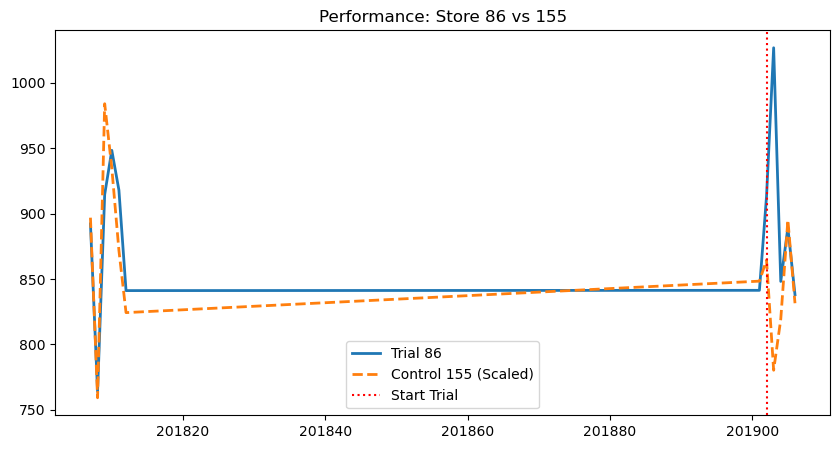

--- HASIL UJI SIGNIFIKANSI ---
Bulan 201902: T-Score 2.18 -> SIGNIFIKAN ✅
Bulan 201903: T-Score 12.23 -> SIGNIFIKAN ✅
Bulan 201904: T-Score 1.36 -> Tidak Signifikan ❌

 ANALISIS TRIAL STORE: 88 
✅ Control Store Terpilih: 237


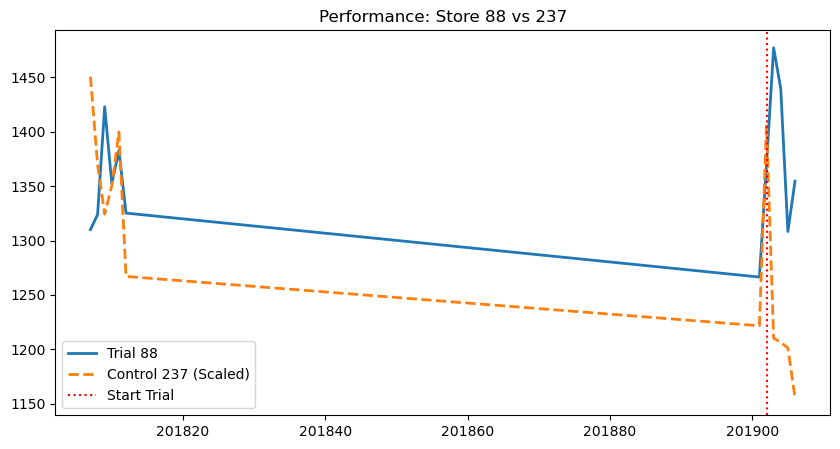

--- HASIL UJI SIGNIFIKANSI ---
Bulan 201902: T-Score -0.78 -> Tidak Signifikan ❌
Bulan 201903: T-Score 6.60 -> SIGNIFIKAN ✅
Bulan 201904: T-Score 5.77 -> SIGNIFIKAN ✅


In [13]:
# --- FUNGSI "ALL-IN-ONE" UNTUK ANALISIS TOKO ---
def analyze_trial_store(trial_store, pretrial_data, measure_data):
    print(f"\n{'='*40}\n ANALISIS TRIAL STORE: {trial_store} \n{'='*40}")
    
    # 1. CARI CONTROL STORE
    # Hitung Sales
    corr_sales = calculate_correlation(pretrial_data, 'totSales', trial_store)
    mag_sales = calculate_magnitude_distance(pretrial_data, 'totSales', trial_store)
    score_sales = pd.merge(corr_sales, mag_sales, on=['Store1', 'Store2'])
    score_sales['scoreNSales'] = 0.5 * score_sales['corr_measure'] + 0.5 * score_sales['mag_measure']

    # Hitung Customer
    corr_cust = calculate_correlation(pretrial_data, 'nCustomers', trial_store)
    mag_cust = calculate_magnitude_distance(pretrial_data, 'nCustomers', trial_store)
    score_cust = pd.merge(corr_cust, mag_cust, on=['Store1', 'Store2'])
    score_cust['scoreNCust'] = 0.5 * score_cust['corr_measure'] + 0.5 * score_cust['mag_measure']

    # Gabung & Ranking
    score_control = pd.merge(score_sales, score_cust, on=['Store1', 'Store2'])
    score_control['finalControlScore'] = 0.5 * score_control['scoreNSales'] + 0.5 * score_control['scoreNCust']
    
    # Ambil Pemenang
    best_control = score_control.sort_values('finalControlScore', ascending=False).iloc[0]['Store2']
    print(f"✅ Control Store Terpilih: {int(best_control)}")
    
    # 2. PLOTTING & ASSESSMENT
    control_store = int(best_control)
    trial_sales = measure_data[measure_data['STORE_NBR'] == trial_store].set_index('YEARMONTH')['totSales']
    control_sales = measure_data[measure_data['STORE_NBR'] == control_store].set_index('YEARMONTH')['totSales']
    
    # Scaling Factor
    scaling_factor = trial_sales[trial_sales.index < 201902].sum() / control_sales[control_sales.index < 201902].sum()
    scaled_control_sales = control_sales * scaling_factor
    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(trial_sales, label=f'Trial {trial_store}', linewidth=2)
    plt.plot(scaled_control_sales, label=f'Control {control_store} (Scaled)', linewidth=2, linestyle='--')
    plt.axvline(x=201902, color='red', linestyle=':', label='Start Trial')
    plt.title(f'Performance: Store {trial_store} vs {control_store}')
    plt.legend()
    plt.show()
    
    # 3. UJI STATISTIK
    percentage_diff = abs(trial_sales - scaled_control_sales) / scaled_control_sales
    std_dev = percentage_diff[percentage_diff.index < 201902].std()
    
    print("--- HASIL UJI SIGNIFIKANSI ---")
    for month in [201902, 201903, 201904]:
        t_val = trial_sales.loc[month]
        c_val = scaled_control_sales.loc[month]
        t_score = (t_val - c_val) / c_val / std_dev
        
        status = "SIGNIFIKAN ✅" if t_score > 2 else "Tidak Signifikan ❌"
        print(f"Bulan {month}: T-Score {t_score:.2f} -> {status}")

# --- EKSEKUSI UNTUK SEMUA TOKO TRIAL ---
# Kita ulangi untuk 77 (buat rekap), 86, dan 88
for store in [77, 86, 88]:
    analyze_trial_store(store, pretrial_data, measureOverTime)

# Recomenndation
1. TRIAL PERFORMANCE EVALUATION:
   - Stores 77 & 88: SHOWED VERY STRONG PERFORMANCE.
     There was a statistically significant increase in sales (T-Score > 2) 
     in March and April 2019 compared to the respective control stores 
     (Stores 233 and 237).
   
   - Store 86: MIXED PERFORMANCE.  
     Although there was a significant increase in March, performance in April 
     returned to normal (not significant). This requires further investigation 
     (was the trial implementation in this store less than optimal?).

2. RECOMMENDATIONS FOR CLIENT (JULIA):
   - STRATEGY ROLL-OUT: Based on the success of Stores 77 and 88, this trial strategy 
     (e.g., layout/promotion changes) has PROVEN EFFECTIVE in increasing sales.
     It is recommended to implement this strategy across the entire store network.
   
   - INVESTIGATE STORE 86: An operational audit should be conducted at Store 86 to 
     understand why the impact did not last as long as in other stores.
     
   - MONITORING: Continue monitoring post-trial performance to ensure 
     the increase in sales is sustainable.

